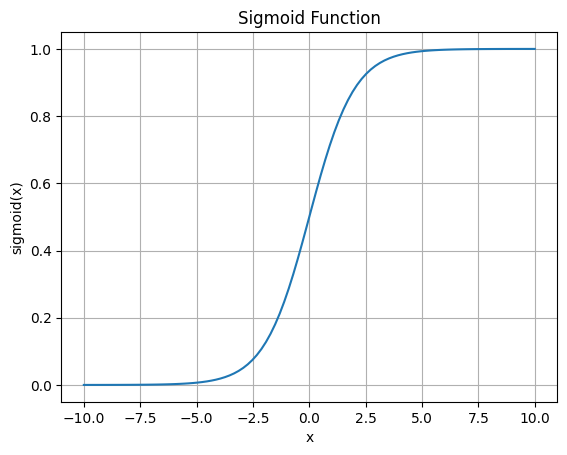

In [2]:
#Type of linear regression :Logistic regression(classification) iski 3 type hai
#used to classify things 
#data ko read krky binary mai daldo true/false,male/female,survived/not survived,0/1 isko binary 
#classification bolty ismai prediction output 2 hoty bs
#multiclass classification A,B,C 2 sy ziada categorical varible hoty predict krne waly e.g sirt color green,blue,yellow
#multilabel classification ismai data ko multiple labels dety e.g animal movie ko kon kon sy label dogy hindi ,bollywood,box office,
#triller,action  ik sy zaida label ik hi cheez ko lagao jb yh use hoti
# dono mai kya same linear or logistic mai ky sare x ka linear combination mil kr y banaty
#yh predict krta probability ky base phr(kis cheez ky accourance ka chnace)0 tw ni  1 tw highly accure 0.5 tw half chance ni hogi
#ismai har class ki probability ki value atti e.g a and b class ik ki probability 0.3,0.7 mtlb ik chance mai a ane ky
#chance 0.3 hai or jisky ziada chance woh predict hogaye gi  is tarah classification algo kaam krta
#logistic mai sigmoid function hota
#The graph of the sigmoid function looks like an S-shaped curve. It is a mathematical function often used in machine learning for binary classification tasks.

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()


In [ ]:
#jb bhi probabilty atti tw function ka center hota or s ki value batati ky center sy value khum tw 0 or 
# usse upper tw 1 e.g center 0.5 center tw 0.4 ko 0 or 0.8 tw 1
#sigmoid function cheez ko probabilty ky mutabiq cheez ko alag krdeta  ya 0 ya 1 value  
#0.5 sy upper waly 1 class mai lein gy or 0.5 sy nechy class 0 mai hogi 0(apple),1(mango)


In [4]:
#logistic regression  is a classification alogorithm used to assign obseravation to a discrete set of classes
#unlike linear regression which is used to predict continuous values,logistic regression transforms it output
#using the logistic sigmoid function to return probability values whcih is then mapped to a discrete set of classes
#logistic regression can be used  for:
#binary classification
#multiclass classification
#one vs rest classification(ik ki pro dheko as compare to other)
#Assumptions of logistic regression:
#the dependent variable must be categorical in nature
#independent variables must be independent.(ik dosre sy independent ho yh)
#there shouldn't be any outliers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder,minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,classification_report

In [14]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
#preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [16]:
#remove deck so much null value
df.drop('deck',axis=1,inplace=True)
#fill missing value(impute)
df['age'].fillna(df['age'].median(),inplace=True)
df['fare'].fillna(df['fare'].median(),inplace=True)#thake outliers affect na kare
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)#q ky alpabetic tha
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)

# label encoding to encode object and categorical data
le=LabelEncoder()
for i in df.columns:
    if df[i].dtypes=='object' or df[i].dtypes=='category':#agar column ka datatype string hai
        df[i]=le.fit_transform(df[i])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1748\1966424719.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1748\1966424719.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [17]:
df# true false ko woh khud handle krleta hai

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,1,1,True,2,0,True
887,1,1,0,19.0,0,0,30.0000,2,0,2,False,2,1,True
888,0,3,0,28.0,1,2,23.4500,2,2,2,False,2,0,False
889,1,1,1,26.0,0,0,30.0000,0,0,1,True,0,1,True


In [18]:
x=df.drop('survived',axis=1)
y=df['survived']

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
model=LogisticRegression()

In [21]:
model.fit(x_train,y_train)

c:\Users\Lenovo\miniconda3\envs\python_ML\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
y_pre=model.predict(x_test)

In [23]:
#evaluate the model
print('Accuracy score:',accuracy_score(y_test,y_pre))#1 tw accuracy achi
print('Recall score :' ,recall_score(y_test,y_pre))
print('Precision metric:',precision_score(y_test,y_pre))
print('F1 score :',f1_score(y_test,y_pre))
print('confusion matrix :',confusion_matrix(y_test,y_pre))
print('classification_report :',classification_report(y_test,y_pre))

Accuracy score: 1.0
Recall score : 1.0
Precision metric: 1.0
F1 score : 1.0
confusion matrix : [[105   0]
 [  0  74]]
classification_report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(95.72222222222221, 0.5, 'actual')

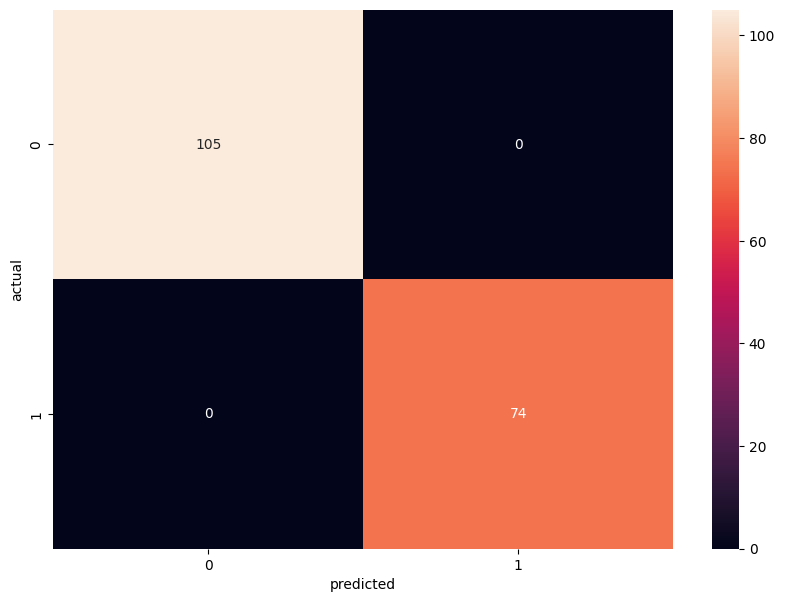

In [30]:
#plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pre),annot=True,fmt='d')#0 wali values ktni ir 1 wali
plt.xlabel('predicted')#dheko acutal 0 thi or model ny bhi usse 0 bola or jtni asal mai 1 thi unko 1 hi kaha isliyh 1 ky against preodiction 0 0 hi hai
plt.ylabel('actual')

In [31]:
#save model
import pickle
pickle.dump(model,open('./saved_models/model_logistic_regression.pkl','wb'))

In [ ]:
#regression
#predict numeric value
#evualtion metrics
#MSE,RMSE,R2,MAE

In [ ]:
#classification
#predict categorical value
#evaluation metrics
#Accuracy(20 value known 20 ky 20 test ky liyh diyh 20 mai sy ktni sahi predict if 20 tw 100% accurate)
#Recall score,Precision score,F1 score,Confusion matrix

In [ ]:
#The main metrics used to evaluate logistic regression models are: Accuracy: The fraction of correct predictions 
# out of the total number of predictions. It is calculated as (correct predictions) / (total predictions). 
# Precision: The fraction of true positive predictions out of all positive predictions. It measures how precise 
# the model is at predicting the positive class. 
# Recall (Sensitivity): The fraction of true positive predictions out of all actual positive instances. It 
# measures how well the model identifies positive instances. F1-Score: The harmonic mean of precision and recall.
# It provides a balanced metric that considers both precision and recall. ROC (Receiver Operating Characteristic) 
# Curve: A plot of the true positive rate (recall) against the false positive rate (1 - specificity) at different 
# classification thresholds. The AUC (Area Under the Curve) is a useful metric derived from the ROC curve. Log 
# Loss (Cross-Entropy Loss): The negative log-likelihood of the true labels given the predicted probabilities. It 
# penalizes confident incorrect predictions more heavily.